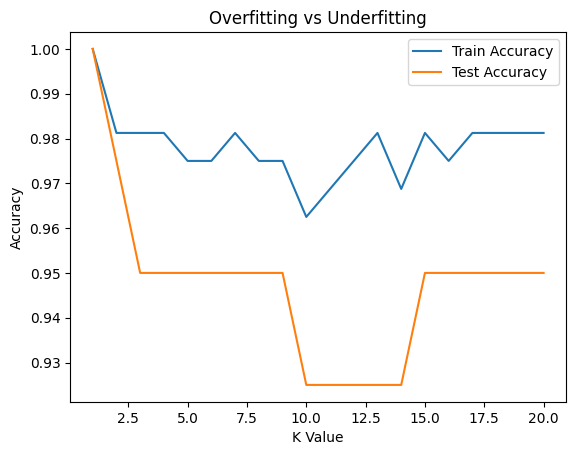

Best K: 1
Best Accuracy: 1.0


In [8]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

np.random.seed(42)

X = np.random.rand(200, 2)
y = (X[:, 0] + X[:, 1] > 1).astype(int)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

train_acc = []
test_acc = []

k_values = range(1, 21)

for k in k_values:
    model = KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train, y_train)

    train_pred = model.predict(X_train)
    test_pred = model.predict(X_test)

    train_acc.append(accuracy_score(y_train, train_pred))
    test_acc.append(accuracy_score(y_test, test_pred))

plt.plot(k_values, train_acc, label="Train Accuracy")
plt.plot(k_values, test_acc, label="Test Accuracy")
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("Overfitting vs Underfitting")
plt.legend()
plt.show()

best_k = np.argmax(test_acc) + 1
print("Best K:", best_k)
print("Best Accuracy:", max(test_acc))